## 중고차 판매 가격 예측: 데이터 분석 개요 및 기초통계

이 노트북은 **중고차 데이터로 회귀분석 전체 흐름을 실행하는 종합실습 솔루션**입니다.
실습 가이드의 순서를 유지하면서, 실행 안정성을 높이기 위한 검증 코드와 제출용 결과 저장 기능을 추가했습니다.

### 완성되는 분석 흐름

`데이터 불러오기 → 구조·기초통계 확인 → EDA → 파생변수 → 전처리 → 상관분석 → Train/Test 분리 → Baseline → OLS 회귀 → Test MAPE → p-value → 실제값/예측값 비교 → 결과 저장`

> **실행 방법:** Google Colab에서 `런타임 → 모두 실행`을 선택하거나, 각 셀을 위에서 아래로 차례대로 실행합니다.  
> **중요:** 아래 설정 셀의 `USER_NAME`을 본인 이름으로 바꾸면 결과 파일명에 자동 반영됩니다.

## 0. 실행 전 체크

- 인터넷 연결이 있으면 원본 CSV를 자동으로 내려받습니다.
- 인터넷 연결이 없으면 노트북과 같은 폴더의 `car_data.csv`를 사용합니다.
- 데이터 로딩이 모두 실패하면 Colab 파일 업로드 창을 띄웁니다.
- 실행 완료 후 제출용 Excel 파일이 자동 생성됩니다.
- 기준 실행 결과는 라이브러리 버전에 따라 소수점 마지막 자리가 조금 달라질 수 있습니다.

### 1. 운영체제별 한글 폰트 설정
#### 1.1 함수 정의 및 실행

In [1]:
import os
import urllib.request
import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def setup_han_font():
    os_name = platform.system()
    print("os_name : "+os_name)
    if os_name == 'Windows':
        font_name = 'Malgun Gothic'

    elif os_name == 'Darwin':  # macOS
        font_name = 'AppleGothic'

    else:  # Linux / Google Colab
        font_name = 'NanumGothic'
        font_file = 'NanumGothic.ttf'
        print("os.path.exists:",os.path.exists(font_file))
        # 1. 폰트 파일이 없을 경우 다운로드
        if not os.path.exists(font_file):
            print("나눔고딕 폰트를 다운로드합니다...")
            url = 'https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf'
            urllib.request.urlretrieve(url, font_file)
            print("다운로드 완료!")

        # 2. 다운로드한 폰트 파일을 matplotlib 파일 매니저에 직접 등록
        fm.fontManager.addfont(font_file)

    # 3. matplotlib 설정 적용
    plt.rcParams['font.family'] = font_name
    plt.rcParams["figure.figsize"] = (8, 5)
    plt.rcParams['axes.unicode_minus'] = False
    print(f"[{os_name}] 환경 한글 폰트('{font_name}') 설정 완료!")

# 운영체제별 한글 폰트 설정 함수 실행 정의 및 실행
setup_han_font()



os_name : Linux
os.path.exists: True
[Linux] 환경 한글 폰트('NanumGothic') 설정 완료!


#### 1.2.matplotlib & shutil 라이브러리를 사용해 해당 캐시 폴더

In [2]:
import shutil
import matplotlib
# 1. 맷플롯립이 폰트 목록을 저장해 둔 임시 캐시 폴더의 '경로'를 찾아옵니다.
cache_dir = matplotlib.get_cachedir()

# 2. 파일 시스템을 다루는 shutil 라이브러리를 사용해 해당 캐시 폴더를 통째로 삭제(rmtree)합니다.
# ignore_errors=True는 폴더가 이미 비어있거나 삭제 중 에러가 나더라도 무시하고 진행하라는 안전장치입니다.
shutil.rmtree(cache_dir, ignore_errors=True)
print("Matplotlib 캐시 폴더를 삭제했습니다. (경로: {})".format(cache_dir))

Matplotlib 캐시 폴더를 삭제했습니다. (경로: /home/codespace/.cache/matplotlib)


### 2. 데이터 불러오기
#### 2.1 원격지에서 csv파일 데이터 읽기.

In [3]:
import pandas as pd
DATA_URL = (
    "https://raw.githubusercontent.com/"
    "amankharwal/Website-data/master/car%20data.csv"
)
LOCAL_CSV = "car_data.csv"

try:
  df = pd.read_csv(DATA_URL)
  print("Successfully loaded data from URL")
except Exception as e:
  print("Failed to load data from URL. Error:", e)
  # If loading from URL fails, try loading from local file
  df = pd.read_csv(LOCAL_CSV)
  print("Successfully loaded data from local file")

# Display the first few rows of the DataFrame  
df.head()


Successfully loaded data from URL


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


#### 2.2 원본 데이터 구조와 품질 확인

필수 컬럼, 행·열 개수, 자료형, 결측치, Target 값의 유효성을 확인합니다.

In [4]:
REQUIRED_COLUMNS = [
    "Car_Name",
    "Year",
    "Selling_Price",
    "Present_Price",
    "Kms_Driven",
    "Fuel_Type",
    "Seller_Type",
    "Transmission",
    "Owner",
]

missing_columns = sorted(set(REQUIRED_COLUMNS) - set(df.columns))
if missing_columns:
    raise ValueError(f"필수 컬럼이 없습니다: {missing_columns}")

if df.empty:
    raise ValueError("데이터가 비어 있습니다.")

numeric_input_cols = [
    "Year",
    "Selling_Price",
    "Present_Price",
    "Kms_Driven",
    "Owner",
]
for column in numeric_input_cols:
    df[column] = pd.to_numeric(df[column], errors="raise")

if (df["Selling_Price"] <= 0).any():
    raise ValueError(
        "MAPE 계산을 위해 Selling_Price는 모두 0보다 커야 합니다."
    )

print("[df.info()]")
df.info()

quality_table = pd.DataFrame(
    {
        "자료형": df.dtypes.astype(str),
        "결측치 수": df.isna().sum(),
        "고유값 수": df.nunique(dropna=False),
    }
)
display(quality_table)

assert df.shape[1] == 9, "원본 데이터는 9개 컬럼이어야 합니다."
print("✅ 원본 데이터 구조 검증 완료")

[df.info()]
<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


,자료형,결측치 수,고유값 수
Car_Name,str,0,98
Year,int64,0,16
Selling_Price,float64,0,156
Present_Price,float64,0,147
Kms_Driven,int64,0,206
Fuel_Type,str,0,3
Seller_Type,str,0,2
Transmission,str,0,2
Owner,int64,0,3


✅ 원본 데이터 구조 검증 완료


#### 2.3 데이터 크기

In [5]:
print("Rows count:",df["Car_Name"].count(),df.shape[0])
print("Columns count:",len(df.columns), df.shape[1])
print("Rows & Columns count:",df.shape)

Rows count: 301 301
Columns count: 9 9
Rows & Columns count: (301, 9)


#### 2.2 데이터 구조
1. 행 개수
2. 컬럼 개수
3. 컬럼명
4. 데이터 타입
5. 결측치
6. 메모리 사용량

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


#### **** 핵심 데이터 요약 해석 ****
1. 데이터의 크기 (행과 열)
RangeIndex: 301 entries, 0 to 300: 이 데이터셋에는 총 301개의 중고차 데이터(행, Rows)가 들어있습니다. 인덱스는 0번부터 300번까지 부여되어 있습니다.

Data columns (total 9 columns): 중고차의 특징을 나타내는 정보(열, Columns)는 총 9개입니다.

2. 결측치(Missing Value)가 없다! ❌ (매우 좋은 신호)
모든 컬럼의 중간을 보면 301 non-null이라고 적혀 있습니다.

전체 301개 데이터 중 비어있는 값(null)이 단 하나도 없이 301개 모두 꽉 차 있다는 뜻입니다. 데이터 분석이나 머신러닝을 시작하기에 아주 깔끔하고 훌륭한 상태입니다. (따로 결측치를 채우는 전처리를 안 하셔도 됩니다!)

3. 데이터 타입(Dtype) 분석
데이터가 어떤 형태(숫자인지 문자인지)로 컴퓨터에 저장되어 있는지 보여줍니다.

float64 (소수점이 있는 실수형 - 2개): Selling_Price(판매 가격), Present_Price(신차 가격)

int64 (소수점이 없는 정수형 - 3개): Year(연식), Kms_Driven(주행거리), Owner(과거 소유자 변경 횟수)

object (문자열/텍스트형 - 4개): Car_Name(차 이름), Fuel_Type(연료), Seller_Type(판매자 유형), Transmission(변속기)

💡 분석가 코멘트: Fuel_Type, Seller_Type, Transmission 같은 object 타입 변수들은 나중에 회귀 분석 모델(OLS)에 넣기 전에 우리가 이전에 했던 것처럼 반드시 원-핫 인코딩(Get Dummies)을 통해 숫자(0과 1) 형태로 변환해주어야 모델이 인식할 수 있습니다.

4. 컴퓨터 메모리 사용량
memory usage: 21.3+ KB: 이 데이터를 처리하기 위해 컴퓨터의 RAM 메모리를 약 21.3KB 정도 쓰고 있다는 뜻입니다. 아주 가볍고 작은 데이터셋이라 컴퓨터에 전혀 무리가 가지 않는 크기입니다.

📝 최종 결론
"총 301대의 중고차 데이터가 9개의 특징 정보로 이루어져 있으며, 구멍 난 데이터(결측치)가 단 하나도 없는 아주 깨끗한 데이터셋입니다. 수치형 데이터와 문자열 데이터가 골고루 섞여 있으므로, 문자열 데이터만 숫자로 잘 바꾸어주면(인코딩) 바로 회귀 분석 모델을 학습시키기에 최적의 상태입니다!"


### 2.3 기초통계와 범주형 빈도

수치형 변수의 범위와 범주형 변수의 구성 비율을 확인합니다.
1. 데이터 개수  - count
2. 평균값      - mean
3. 표준편차     - std
4. 최소값       - min
5. 제1사분위수  - 25%
6. 중앙값       - Median
7. 제3사분위수  - 75%
8. 최대값       - max

In [7]:
print("[수치형 변수 기초통계]")
display(df.describe().T)

for column in ["Fuel_Type", "Seller_Type", "Transmission"]:
    counts = df[column].value_counts(dropna=False).rename("count").to_frame()
    counts["ratio(%)"] = counts["count"] / len(df) * 100
    print(f"\n[{column} 빈도(비율-레이시오)]")
    display(counts)

[수치형 변수 기초통계]


,count,mean,std,min,25%,50%,75%,max
Year,301.0,2013.627907,2.891554,2003.00,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,4.661296,5.082812,0.10,0.9,3.6,6.0,35.0
Present_Price,301.0,7.628472,8.644115,0.32,1.2,6.4,9.9,92.6
Kms_Driven,301.0,36947.205980,38886.883882,500.00,15000.0,32000.0,48767.0,500000.0
Owner,301.0,0.043189,0.247915,0.00,0.0,0.0,0.0,3.0



[Fuel_Type 빈도(비율-레이시오)]


,count,ratio(%)
Fuel_Type,,
Petrol,239,79.401993
Diesel,60,19.933555
CNG,2,0.664452



[Seller_Type 빈도(비율-레이시오)]


,count,ratio(%)
Seller_Type,,
Dealer,195,64.784053
Individual,106,35.215947



[Transmission 빈도(비율-레이시오)]


,count,ratio(%)
Transmission,,
Manual,261,86.710963
Automatic,40,13.289037


### 3. EDA: 주요 변수 분포

- `Selling_Price`: 예측 대상인 실제 판매 가격
- `Present_Price`: 신차 당시 가격
- `Kms_Driven`: 총주행거리

분포의 치우침과 높은 값의 존재 여부를 확인합니다.

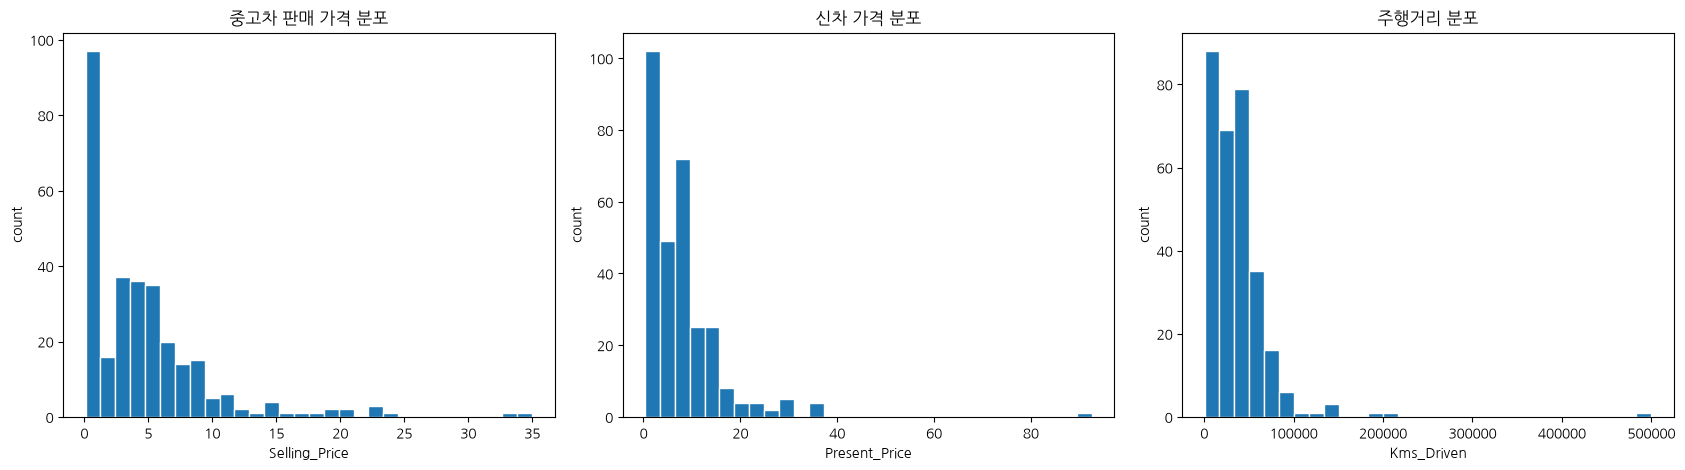

[왜도: 양수가 클수록 오른쪽 꼬리가 긴 분포]


,skewness
Selling_Price,2.493422
Present_Price,4.083150
Kms_Driven,6.436013


In [8]:
plot_specs = [
    ("Selling_Price", "중고차 판매 가격 분포", "Selling_Price"),
    ("Present_Price", "신차 가격 분포", "Present_Price"),
    ("Kms_Driven", "주행거리 분포", "Kms_Driven"),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for axis, (column, title, xlabel) in zip(axes, plot_specs):
    axis.hist(df[column], bins=30, edgecolor="white")
    axis.set_title(title)
    axis.set_xlabel(xlabel)
    axis.set_ylabel("count")
plt.tight_layout()
plt.show()

skewness = df[["Selling_Price", "Present_Price", "Kms_Driven"]].skew()
print("[왜도: 양수가 클수록 오른쪽 꼬리가 긴 분포]")
display(skewness.rename("skewness").to_frame())

### **** 왜도(Skewness) ****
왜도(Skewness-왜도(歪度)**의 '왜'는 '삐뚤어질 왜' 자)는 데이터의 분포가 평균을 기준으로 어느 쪽으로 얼마나 치우쳐져 있는지(비대칭성-Skewness)를 나타내는 통계적 지표입니다.

쉽게 말해, "데이터의 꼬리가 어느 쪽으로 길게 늘어져 있는가?"를 숫자로 표현한 것입니다.

현재 작성하신 코드 결과창에 찍힌 수치들을 이해하기 쉽게 완벽하게 정리해 드릴게요.

1. 왜도 수치별 분포 모양 해석
    왜도는 0을 기준으로 값이 결정됩니다.

    ① 왜도가 + (양수)인 경우: 오른쪽으로 꼬리가 긴 분포 ➔ ⚠️ 현재 중고차 데이터
    모양: 왼쪽으로 데이터가 잔뜩 몰려있고, 오른쪽(큰 값)으로 갈수록 꼬리가 길게 늘어집니다.

    의미: 대부분의 데이터는 작은 값에 모여 있지만, 유독 아주 큰 값을 가진 극단적인 데이터(이상치)가 몇 개 존재한다는 뜻입니다.

    현재 데이터 해석: Selling_Price, Present_Price, Kms_Driven 모두 왜도가 매우 큰 양수로 나올 것입니다. 왜냐하면 대부분의 중고차는 가격이 낮고 주행거리가 짧지만, 일부 슈퍼카(Present_Price가 매우 높음)나 엄청 많이 탄 차(Kms_Driven 50만km)들이 오른쪽에 길게 꼬리를 늘리고 있기 때문입니다.

② 왜도가 0에 가까운 경우: 좌우 대칭 분포
    모양: 좌우가 예쁘게 대칭을 이루는 종 모양(정규분포)입니다.

    의미: 평균을 중심으로 데이터가 아주 고르게 퍼져 있음을 뜻합니다. 머신러닝 회귀 모델이 가장 좋아하는 이상적인 형태입니다.

③ 왜도가 - (음수)인 경우: 왼쪽으로 꼬리가 긴 분포
    모양: 오른쪽(큰 값)에 데이터가 몰려있고, 왼쪽(작은 값)으로 꼬리가 길게 늘어집니다.

    의미: 대부분의 데이터가 큰 값에 치우쳐 있고, 유독 아주 작은 값을 가진 데이터가 적게 존재한다는 뜻입니다. (예: 대다수가 높은 점수를 받은 쉬운 시험의 성적 분포)

2. 데이터 분석가에게 왜도가 중요한 이유
    선형 회귀 모델(OLS)은 독립 변수와 타겟 변수가 좌우 대칭인 정규분포(왜도 0 근처)를 이룰 때 가장 높은 예측 성능을 발휘합니다.

    현재 코드에서 세 변수의 왜도를 확인하신 건 아주 훌륭한 접근입니다. 만약 왜도가 1 이상(또는 2 이상)으로 너무 크게 나온다면, 모델이 학습할 때 큰 숫자들에 눈이 멀어 예측력이 떨어질 수 있습니다.

💡 왜도 코드를 본 후 취해야 할 액션 (로그 변환)
    만약 Selling_Price.skew() 결과가 너무 높게 나왔다면, 앞서 뒤쪽에나올 로그 변환(model.predict 또는 np.log1p)을 적용해야 합니다. 로그를 취하면 길었던 오른쪽 꼬리가 마법처럼 안으로 접혀 들어오면서 왜도가 0에 가깝게 줄어들고, 모델의 예측 정확도가 대폭 상승하게 됩니다!

### 4. 파생변수 생성

두 개의 파생변수를 만듭니다.

- `Car_Age(차량 연식) = 기준 연도(올해) - Year(제조 연도) + 1`
- `Kms_Per_Year(연평균 주행거리) = Kms_Driven(주행거리) / Car_Age`

가장 최근 제조 연도의 다음 해를 기준 연도로 사용하므로 `Car_Age`가 0이 되지 않습니다.
파생변수 생성 기준 의미

예: 2026년식 신차: 2026 - 2026 + 1 = 1년 차 (올해 출고)

| 파생변수 | 생성 기준 | 의미 |
| :--- | :---: | ---: |
| Car_Age | 현재 연도 - 제조 연도 + 1 | 차량 연식 |
| Kms_Per_Year | 주행거리 / 차량 | 연평균 주행거리 |


In [9]:
# cf: 오토바이 데이터를 과감히 필터링하고 '자동차'만 남기기
# (또는 신차 가격이 일정 수준 이상인 데이터만 타겟으로 잡기)
#df_car = df[df['Present_Price'] >= 1.0]


# 1. 연식 데이터를 나이 데이터로 정확히 변환하기
# 현재 시점의 연도를 동적으로 가져옴 (예: 2026)
from datetime import datetime
current_year = datetime.now().year

# 2. 자동으로 계산된 현재 연도를 기준으로 차량 나이(Car_Age) 계산
# 2026년식 신차: 2026 - 2026 + 1 = 1년 차 (올해 출고)
df['Car_Age'] = current_year - df['Year'] + 1

# 3.주행거리 단위를 천(1,000)으로 나누어 숫자의 크기를 줄여줍니다. (예: 43000 -> 43.0)
df['Kms_Driven'] = df['Kms_Driven'] / 1000
df["Kms_Per_Year"] = df["Kms_Driven"] / df["Car_Age"]

# 4. 데이터 정합성 체크: Car_Age가 0 이하인 경우와 Kms_Per_Year가 무한대 또는 비정상 값이 있는지 확인
import numpy as np
if (df["Car_Age"] <= 0).any():
    raise ValueError("Car_Age에 0 이하 값이 발생했습니다.")

if not np.isfinite(df["Kms_Per_Year"]).all():
    raise ValueError("Kms_Per_Year에 무한대 또는 비정상 값이 있습니다.")

print("기준 연도:", current_year)
display(
    df[
        ["Year", "Car_Age", "Kms_Driven", "Kms_Per_Year"]
    ].head(10)
)

기준 연도: 2026


,Year,Car_Age,Kms_Driven,Kms_Per_Year
0,2014,13,27.000,2.076923
1,2013,14,43.000,3.071429
2,2017,10,6.900,0.690000
3,2011,16,5.200,0.325000
4,2014,13,42.450,3.265385
5,2018,9,2.071,0.230111
6,2015,12,18.796,1.566333
7,2015,12,33.429,2.785750
8,2016,11,20.273,1.843000
9,2015,12,42.367,3.530583


### 5. 회귀분석용 데이터 전처리

5.1. 모델명이자 고유 범주가 많은 `Car_Name` 제거

5.2. `Car_Age`로 대체된 `Year` 제거

In [10]:
model_df = df.drop(columns=["Car_Name", "Year"]).copy()

5.3. 범주형 변수 원-핫 인코딩
원-핫 인코딩(One-Hot Encoding)이란?

원-핫 인코딩은 범주형 변수의 고유한 값(클래스)들을 새로운 독립된 열(Column)로 만들고, 해당하는 데이터에는 1, 나머지 열에는 0을 부여하는 방식입니다.

💡 왜 '원-핫(One-Hot)'일까?

수많은 0 중에서 **단 하나만 1(Hot)**로 켜진 상태의 컴퓨터 회로 신호에서 유래된 이름입니다.

📊 시각적 예시 (Fuel_Type 변수 변경 과정)

기본 데이터에 Fuel_Type이라는 변수가 있고, 값으로 [Gasoline, Diesel, CNG]가 있다고 가정해 봅시다.

[변경 전 구조]

| ID | Fuel_Type | 
| :---: | :--- | 
| 1 | Gasoline | 
| 2 | Diesel | 
| 3 | CNG | 
| 4 | Gasoline | 

...

[변경 전 구조]

| ID | Fuel_Type_Gasoline |  Fuel_Type_Diesel | Fuel_Type_CNG |
| :---: | :---: |  :---: |   :---: | 
| 1 | 1 |  0 |  0 | 
| 2 | 0 |  1 |  0 | 
| 3 | 0 |  0 |  1 | 
| 3 | 1 |  0 |  0 | 

💡 왜 그냥 1, 2, 3으로 바꾸면 안 될까요? (Label Encoding의 한계)

"그냥 Gasoline = 1, Diesel = 2, CNG = 3으로 바꾸면 열도 안 늘어나고 편하지 않나요?"라는 의문이 들 수 있습니다. 이 방식을 레이블 인코딩(Label Encoding)이라고 합니다.

하지만 회귀분석에서 이 방식을 쓰면 심각한 문제가 발생합니다.

💡 변수들의 변환 예측 예시
질문하신 세 가지 변수가 원-핫 인코딩을 거치면 데이터프레임이 아래처럼 확장됩니다.

① Fuel_Type (연료 종류)

고유값: Gasoline, Diesel, CNG

생성되는 열: Fuel_Type_Gasoline, Fuel_Type_Diesel, Fuel_Type_CNG

② Seller_Type (판매자 유형)

고유값: Dealer, Individual (딜러, 개인)

생성되는 열: Seller_Type_Dealer, Seller_Type_Individual

③ Transmission (변속기)

고유값: Manual, Automatic (수동, 자동)

생성되는 열: Transmission_Manual, Transmission_Automatic

💡 ⚠️ 회귀분석 시 주의할 점: 다중공선성과 가선택(Dummy Variable Trap)

원-핫 인코딩을 회귀분석에 적용할 때 반드시 알아야 할 통계학적 주의점이 있습니다. 바로 다중공선성(Multicollinearity) 문제입니다.

예를 들어, Transmission_Manual이 1이면 Transmission_Automatic은 무조건 0이 됩니다. 반대로 Manual이 0이면 Automatic은 무조건 1이죠. 즉, 한쪽 열을 알면 다른 쪽 열을 100% 완벽하게 예측할 수 있습니다.

이렇게 변수 간에 과도한 상관관계가 생기면 회귀 모델의 회귀 계수(Weight)가 불안정해져 분석 결과가 망가집니다.

🛠️ 해결책: 열 하나를 삭제하기 (Drop First)

그래서 실제 회귀분석을 할 때는 원-핫 인코딩으로 생긴 열 중 변수당 하나씩을 삭제합니다.

Transmission_Manual 열 하나만 남겨둡니다.

이 값이 1이면 수동(Manual)

이 값이 0이면 자동(Automatic)을 의미하므로 변수 하나로도 두 상태를 완벽히 표현할 수 있습니다.

마찬가지로 Fuel_Type도 3개의 열 중 1개를 지운 2개의 열만 사용합니다. (남은 두 열이 모두 0이면 지워진 종류를 의미하게 됨)

Python의 Pandas 라이브러리를 사용할 때 pd.get_dummies(df, drop_first=True) 옵션을 주는 이유가 바로 이 다중공선성을 방지하기 위함입니다.

In [11]:
categorical_cols = ["Fuel_Type", "Seller_Type", "Transmission"]
model_df = pd.get_dummies(
    model_df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int,
)
display(model_df.head())

,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Kms_Per_Year,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27.00,0,13,2.076923,0,1,0,1
1,4.75,9.54,43.00,0,14,3.071429,1,0,0,1
2,7.25,9.85,6.90,0,10,0.690000,0,1,0,1
3,2.85,4.15,5.20,0,16,0.325000,0,1,0,1
4,4.60,6.87,42.45,0,13,3.265385,1,0,0,1


5.4. 결측치와 문자열 컬럼 잔존 여부 확인

In [13]:
remaining_object_cols = model_df.select_dtypes(include="object").columns.tolist()
missing_count = int(model_df.isna().sum().sum())

print("결측치 개수:", missing_count)
print("문자열 컬럼:", remaining_object_cols)
print("전처리 후 컬럼 수:", model_df.shape[1])
print("컬럼 목록:", model_df.columns.tolist())


assert missing_count == 0, "전처리 후 결측치가 남아 있습니다."
assert not remaining_object_cols, "문자형 컬럼이 남아 있습니다."
print("✅ 회귀분석용 데이터 전처리 검증 완료")

결측치 개수: 0
문자열 컬럼: []
전처리 후 컬럼 수: 10
컬럼 목록: ['Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner', 'Car_Age', 'Kms_Per_Year', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Seller_Type_Individual', 'Transmission_Manual']
✅ 회귀분석용 데이터 전처리 검증 완료


## 6. 상관분석

### 6.1 종속변수(Target변수)과 설명변수(Feature/독립변수)

`종속변수(Selling_Price)`와의 **상관계수 절댓값**이 큰 순서대로 정렬합니다. 상관계수는 선형적인 동반 변화를 나타낼 뿐, 인과관계를 증명하지는 않습니다.

### 6.2 상관계수(Correlation Coefficient)와 '절댓값'의 의미

상관계수(보통 $r$로 표기)는  두 변수가 서로 얼마나 직선(선형) 형태로 같이 움직이는가를 나타내는 -1부터 1 사이의 숫자입니다.

`양의 상관관계 ($r > 0$)`: 한 변수가 커질 때 다른 변수도 같이 커지는 관계 (예: 연식이 최신일수록 Selling_Price가 올라간다).

`음의 상관관계 ($r < 0$)`: 한 변수가 커질 때 다른 변수는 작아지는 관계 (예: 주행거리가 길어질수록 Selling_Price가 떨어진다).

### 6.3. "선형적인 동반 변화를 나타낼 뿐, 인과관계를 증명하지 않는다"

이 표현은 통계학에서 가장 중요한 명제인 "상관관계는 인과관계를 의미하지 않는다 (Correlation is not causation)"를 말합니다.

선형적인 동반 변화 (상관관계): A가 움직일 때 B가 일정한 패턴으로 같이 움직인다는 '사실'입니다.

인과관계: A가 '원인'이 되어 B라는 '결과'가 나타났다는 구조적 관계입니다.

🚗 중고차 데이터로 보는 예시

데이터를 분석했더니 "차량 안에 장착된 내비게이션 화면의 크기"와 Selling_Price의 상관계수가 매우 높게(예: 0.75) 나왔다고 가정해 봅시다.

단순한 해석 (상관관계): 내비게이션 화면이 큰 차일수록 중고차 가격이 비싸구나! (참)

잘못된 오류 (인과관계 착각): "내 중고차를 비싸게 팔고 싶으니, 옥션에서 제일 큰 모니터를 사서 달아야겠다!" (거짓)

내비게이션 화면이 커서 차가 비싸진 것이 아니라, 최신 연식의 고급 대형차(제3의 원인)에 원래 큰 화면의 내비게이션이 탑재되어 있고 가격도 비싼 
것뿐입니다. 즉, 두 변수는 같이 움직일 뿐이지 서로가 원인과 결과는 아닙니다.

🛠️ 결론: 분석가가 해야 할 일

상관계수가 높은 순으로 변수를 정렬하는 것은 "예측 모델에 먼저 집어넣을 좋은 후보 변수들을 고르는 작업"으로서는 훌륭합니다.

다만, 회귀 모델을 만들 때는 이 숫자를 맹신하기보다 "이 변수가 실제로 가격 결정에 논리적인 원인이 되는가?"를 도메인 지식(자동차 시장에 대한 상식)을 바탕으로 함께 검토해야 탄탄하고 왜곡 없는 회귀분석 모델을 완성할 수 있습니다.

In [14]:
corr = model_df.corr(numeric_only=True)
target_corr = corr["Selling_Price"].drop("Selling_Price")
target_corr_sorted = target_corr.loc[
    target_corr.abs().sort_values(ascending=False).index
]
target_corr_top2 = target_corr_sorted.head(2)

print("[Selling_Price와의 상관계수: 절댓값 기준 정렬]")
display(target_corr_sorted.rename("correlation").to_frame())

print("[종속변수와 상관성이 높은 2개 변수]")
display(target_corr_top2.rename("correlation").to_frame())

[Selling_Price와의 상관계수: 절댓값 기준 정렬]


,correlation
Present_Price,0.878983
Fuel_Type_Diesel,0.552339
Seller_Type_Individual,-0.550724
Fuel_Type_Petrol,-0.540571
Transmission_Manual,-0.367128
Car_Age,-0.236141
Kms_Per_Year,0.118445
Owner,-0.088344
Kms_Driven,0.029187


[종속변수와 상관성이 높은 2개 변수]


,correlation
Present_Price,0.878983
Fuel_Type_Diesel,0.552339


#### 6.4 설명변수 간 상관관계

설명변수끼리 상관관계가 지나치게 높으면 회귀계수와 p-value가 불안정해질 수 있습니다. 


In [15]:
X_all = model_df.drop(columns=["Selling_Price"])
feature_corr = X_all.corr(numeric_only=True)
feature_corr

,Present_Price,Kms_Driven,Owner,Car_Age,Kms_Per_Year,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
Present_Price,1.000000,0.203647,0.008057,0.047584,0.253184,0.473306,-0.465244,-0.512030,-0.348715
Kms_Driven,0.203647,1.000000,0.089216,0.524342,0.966545,0.172515,-0.172874,-0.101419,-0.162510
Owner,0.008057,0.089216,1.000000,0.182104,0.044111,-0.053469,0.055687,0.124269,-0.050316
Car_Age,0.047584,0.524342,0.182104,1.000000,0.377177,-0.064315,0.059959,0.039896,-0.000394
Kms_Per_Year,0.253184,0.966545,0.044111,0.377177,1.000000,0.264654,-0.264909,-0.180534,-0.160278
Fuel_Type_Diesel,0.473306,0.172515,-0.053469,-0.064315,0.264654,1.000000,-0.979648,-0.350467,-0.098643
Fuel_Type_Petrol,-0.465244,-0.172874,0.055687,0.059959,-0.264909,-0.979648,1.000000,0.358321,0.091013
Seller_Type_Individual,-0.512030,-0.101419,0.124269,0.039896,-0.180534,-0.350467,0.358321,1.000000,0.063240
Transmission_Manual,-0.348715,-0.162510,-0.050316,-0.000394,-0.160278,-0.098643,0.091013,0.063240,1.000000


히트맵과 상위 변수쌍을 함께 확인합니다.

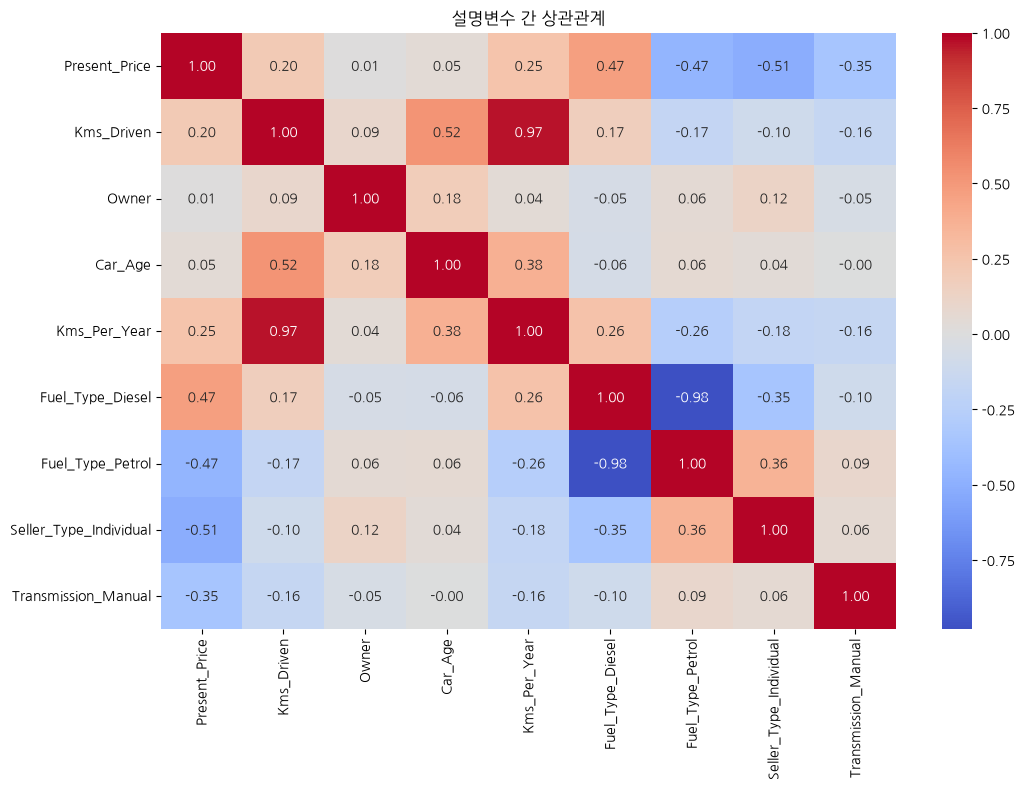

In [16]:
import seaborn as sns

plt.figure(figsize=(11, 8))
sns.heatmap(
    feature_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=False,
)
plt.title("설명변수 간 상관관계")
plt.tight_layout()
plt.show()

설명변수 간 상관성이 높은 2개 Pair 찾기

In [17]:
import numpy as np

upper_mask = np.triu(np.ones(feature_corr.shape), k=1).astype(bool)
corr_pairs = feature_corr.where(upper_mask).stack()
top_feature_pairs = corr_pairs.loc[
    corr_pairs.abs().sort_values(ascending=False).head(2).index
]

pair_rows = []
for (var_1, var_2), value in top_feature_pairs.items():
    pair_rows.append(
        {"변수 1": var_1, "변수 2": var_2, "상관계수": value}
    )
top_feature_pairs_df = pd.DataFrame(pair_rows)

print("[설명변수 간 상관성이 높은 2개 Pair]")
display(top_feature_pairs_df)

[설명변수 간 상관성이 높은 2개 Pair]


,변수 1,변수 2,상관계수
0,Fuel_Type_Diesel,Fuel_Type_Petrol,-0.979648
1,Kms_Driven,Kms_Per_Year,0.966545


### 7. Train(모델학습-데이터훈련)/Test(모델평가-검증) 분리와 수치형 변수 스케일링

전체 데이터의 70%를 Train, 30%를 Test로 나눕니다. Min-Max Scaler는 **Train 데이터에만 적합(fit)**하고, 같은 기준을 Test 데이터에 적용하여 데이터 누수를 방지합니다.

#### 7.1. 종속변수와 설명변수 분리

In [18]:
X = model_df.drop(columns=["Selling_Price"])
y = model_df["Selling_Price"]

#### 7.2. Train(모델학습)/Test(모델평가) 분리

from sklearn.model_selection import train_test_split은 파이썬의 대표적인 머신러닝 라이브러리인 Scikit-learn(사이킷런)에서 데이터를 훈련용(Train)과 검증용(Test)으로 나누어주는 함수입니다.

1. 데이터를 왜 나누어야 할까요?

공부에 비유하자면 머신러닝 모델은 '학생'이고, 데이터는 '문제집'입니다.

만약 학생에게 문제집의 홀수 번 문제로 공부(훈련)를 시킨 뒤, 똑같이 홀수 번 문제로 시험(검증)을 보면 어떻게 될까요? 학생이 문제의 개념을 완벽히 이해하지 못하고 단순히 답을 외우기만 했어도 100점을 맞을 수 있습니다. 이것을 머신러닝에서는 과적합(Overfitting, 기출문제에만 달달 외워 적응함)이라고 합니다.

따라서 모델이 새로운 데이터(처음 보는 문제)도 잘 맞추는 진짜 실력을 가졌는지 평가하려면, 공부할 때 쓸 문제(Train Data)와 시험 볼 때 쓸 문제(Test Data)를 반드시 분리해야 합니다.

2. train_test_split 함수의 주요 역할과 파라미터

⚙️ 핵심 파라미터(옵션) 설명

X, y: 분할할 데이터입니다. X는 설명변수(Feature, 힌트), y는 타겟변수(Target, 정답)입니다.

test_size=0.2: 전체 데이터 중 몇 %를 시험(Test)용으로 쓸지 결정합니다. 0.2라면 훈련용 80%, 시험용 20%로 나눕니다. (보통 7:3 또는 8:2 분할을 가장 많이 씁니다.)

random_state=42: 데이터를 무작위로 섞을 때 사용하는 시드(Seed) 번호입니다. 이 숫자를 고정해두면 코드를 내일 실행하든, 다른 컴퓨터에서 실행하든 항상 똑같은 방식으로 데이터가 쪼개집니다. (결과의 재현성을 위해 필수적이며, 숫자는 아무거나 적어도 상관없습니다.)

stratify=y (선택 옵션): 분류(Classification) 문제에서 매우 중요한 옵션입니다. 타겟(y)의 클래스 비율(예: 정상차 90%, 침수차 10%)을 유지하면서 훈련/시험 데이터를 쪼개줍니다. 한쪽에만 특정 정답이 몰리는 것을 방지합니다.

3. 함수가 반환하는 4개의 결과물

코드를 실행하면 4개의 덩어리가 튀어나오는데, 순서가 항상 일정하므로 이 구조를 외워두시는 게 좋습니다.

X_train: 모델을 학습(공부)시킬 때 쓸 설명변수 (문제집의 학습용 문제)

X_test: 모델을 시험(평가)할 때 쓸 설명변수 (시험지 문제)

y_train: X_train에 대한 정답 (문제집의 학습용 해설)

y_test: X_test에 대한 정답 (시험지 채점용 모범답안)

이 과정을 거쳐 나온 X_train과 y_train으로 모델을 학습(.fit())시키고, 이후 X_test를 모델에 넣어 예측값을 만든 뒤 실제 정답인 y_test와 비교하여 모델의 최종 점수를 매기게 됩니다.


In [19]:
# 1. 데이터 쪼개기
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.3,
random_state=42,
shuffle=True
)

print("\n[데이터 쪼개기 결과]")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


[데이터 쪼개기 결과]
X_train: (210, 9)
X_test: (91, 9)
y_train: (210,)
y_test: (91,)


#### 7.3. 스케일링(Scaling)이란?
데이터를 훈련용(Train)과 시험용(Test)으로 쪼갠 직후에 진행하는 스케일링(Scaling, 데이터 표준화/정규화)은 변수들의 단위(단위의 크기)를 일정하게 맞춰주는 작업을 말합니다.

왜 이 작업을 해야 하는지, 그리고 반드시 데이터를 쪼갠 후에 해야 하는 이유를 쉽게 설명해 드릴게요.

** 중고차 데이터를 예로 들어 보겠습니다.

연식(Year): 보통 2015, 2018, 2022 등 천 단위의 숫자입니다.

주행거리(Kms_Driven): 50000, 120000 등 만~십만 단위의 숫자입니다.

연료 종류(원-핫 인코딩 후): 0 또는 1입니다.

이렇듯 데이터의 최솟값과 최댓값의 범위(스케일)가 서로 판이하게 다른 상태를, 특정 공식(StandardScaler, MinMaxScaler 등)을 사용하여 모든 변수의 범위를 비슷하게(예: 0~1 사이 또는 평균 0, 표준편차 1) 맞춰주는 것이 스케일링입니다.

2. 스케일링을 왜 해야 할까요?

① 숫자가 크면 무조건 중요한 줄 아는 '모델의 착각' 방지
회귀분석(특히 경사하강법을 쓰는 모델이나 릿지/라쏘 같은 규제 모델)은 숫자의 절대적인 크기에 큰 영향을 받습니다.
모델 입장에서는 주행거리의 100,000이라는 숫자가 연식의 2020이나 연료 종류의 1보다 수십~수십만 배 더 거대하고 중요한 변수라고 착각하게 됩니다. 실제로는 연식이 가격에 더 큰 영향을 미칠 수 있는데도 말이죠. 스케일링을 하면 모든 변수가 동일한 선상에서 공평하게 비교됩니다.

② 모델의 학습 속도 및 안정성 향상

스케일이 들쭉날쭉하면 모델이 최적의 회귀 계수(Weight)를 찾아가는 과정에서 헤매게 되어 학습 시간이 오래 걸리거나, 아예 엉뚱한 값을 도출할 수 있습니다. 스케일링을 해주면 경사하강법 등의 최적화 알고리즘이 훨씬 빠르고 안정적으로 중심을 찾아갑니다.

3. 왜 반드시 '데이터를 쪼갠 후에' 스케일링을 해야 할까?

이 부분이 데이터 분석에서 가장 많이 실수하는 핵심 포인트입니다. 결론부터 말씀드리면 데이터 누수(Data Leakage)를 막기 위해서입니다.

만약 데이터를 쪼개기 전에 전체 데이터의 평균과 표준편차로 스케일링을 해버리면 어떻게 될까요?

훈련 데이터(Train) 안에 미래에 시험 볼 데이터(Test)의 평균 정보가 야금야금 스며들게 됩니다.

이는 시험을 보기 전에 모의고사 문제집에 실제 시험 문제의 힌트나 평균 점수가 적혀있는 것과 같습니다.

🛠️ 올바른 스케일링 순서와 코드 흐름

따라서 반드시 먼저 데이터를 쪼갠 후, 훈련 데이터(X_train)의 기준(평균, 표준편차 등)을 학습하여 시험 데이터(X_test)에 적용해야 합니다.

In [20]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
numeric_cols = [
"Present_Price",
"Kms_Driven",
"Owner",
"Car_Age",
"Kms_Per_Year"
]
print("\n[Train 스케일링 전 수치형 변수]")
display(X_train_scaled.head())
display(X_train_scaled[numeric_cols].describe().loc[["min", "max"]])

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
#from sklearn.preprocessing import StandardScaler
#scaler = StandardScaler()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols]) # 훈련 데이터로 fit하고 transform!

print("\n[Train 스케일링 후 수치형 변수]")
display(X_train_scaled.head())
display(X_train_scaled[numeric_cols].describe().loc[["min", "max"]])


[Train 스케일링 전 수치형 변수]


,Present_Price,Kms_Driven,Owner,Car_Age,Kms_Per_Year,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
185,0.58,1.900,0,19,0.100000,0,1,1,0
72,18.61,56.001,0,14,4.000071,0,1,0,1
15,10.79,43.000,0,11,3.909091,1,0,0,1
10,3.60,2.135,0,10,0.213500,0,1,0,1
196,0.52,500.000,0,19,26.315789,0,1,1,0


,Present_Price,Kms_Driven,Owner,Car_Age,Kms_Per_Year
min,0.47,0.5,0.0,10.0,0.045455
max,92.60,500.0,3.0,24.0,26.315789



[Train 스케일링 후 수치형 변수]


,Present_Price,Kms_Driven,Owner,Car_Age,Kms_Per_Year,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
185,0.001194,0.002803,0.0,0.642857,0.002076,0,1,1,0
72,0.196896,0.111113,0.0,0.285714,0.150535,0,1,0,1
15,0.112016,0.085085,0.0,0.071429,0.147072,1,0,0,1
10,0.033974,0.003273,0.0,0.000000,0.006397,0,1,0,1
196,0.000543,1.000000,0.0,0.642857,1.000000,0,1,1,0


,Present_Price,Kms_Driven,Owner,Car_Age,Kms_Per_Year
min,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0


### 8. Baseline 모델

Train 데이터의 평균 판매 가격을 모든 Test 데이터의 예측값으로 사용하는 가장 단순한 기준 모델입니다. 이후 회귀모델의 Test MAPE가 이 값보다 낮아야 개선되었다고 판단합니다.

베이스라인 모델(Baseline Model)은 머신러닝/데이터 분석 프로젝트에서 가장 먼저 만들어보는 '기준점' 모델을 말합니다.

쉽게 말해, 시험을 보기 전에 "아무 공부도 안 하고 상식선에서 풀었을 때 몇 점이 나오는가?"를 확인하는 작업입니다. 이 기준 점수가 있어야 앞으로 내가 모델을 수정하고 업그레이드했을 때 "얼마나 더 좋아졌는지"를 객관적으로 평가할 수 있습니다.

#### 8.1. 각 지표별 상세 해석
① Baseline 예측값: 4.5732

의미: 모델이 테스트 데이터의 정답을 맞추기 위해 일괄적으로 제시한 예측 기준값입니다.

해석: 가장 단순한 형태의 베이스라인 모델(예: 타깃 변수의 평균값으로 찍는 모델)을 사용하셨다면, 모델은 데이터의 특성을 고려하지 않고 모든 데이터의 정답을 대략 4.57 전후로 예측하고 있습니다.

② Baseline MAPE: 3.3820

의미: MAPE는 평균 절대 백분율 오차(Mean Absolute Percentage Error)를 소수로 표현한 것입니다.

해석: 실제 정답과 모델이 예측한 값 사이에 평균적으로 3.38배 크기의 오차가 나고 있다는 뜻입니다.

③ Baseline MAPE(%): 338.20%

의미: 위의 MAPE 소수값에 100을 곱해 직관적인 퍼센트(%)로 나타낸 것입니다.

해석: "실제 정답 대비 예측 오차가 평균 338.2%이다"라는 뜻입니다. 예를 들어 실제 중고차 가격이 100만 원이라면, 모델은 338만 원 정도를 더 높게 부르거나 낮게 불러서 438만 원 또는 -238만 원(음수 불가 시 터무니없는 값)으로 예측하는 수준이라는 의미입니다.

In [21]:
from sklearn.metrics import mean_absolute_percentage_error
baseline_value = y_train.mean()
baseline_pred = np.repeat(baseline_value, len(y_test))
baseline_mape = mean_absolute_percentage_error(y_test, baseline_pred)
print(f"Baseline 예측값:{baseline_value:.4f}")
print(f"Baseline MAPE:{baseline_mape:.4f}")
print(f"Baseline MAPE(%):{baseline_mape * 100:.2f}%")

Baseline 예측값:4.5732
Baseline MAPE:3.3820
Baseline MAPE(%):338.20%


### 9. statsmodels OLS 회귀모델

상수항을 추가한 뒤 Ordinary Least Squares 회귀모델을 학습합니다. 우선 확인할 항목은 `coef`, `P>|t|`, `R-squared`, `Adj. R-squared`, `Prob(F-statistic)`입니다.

statsmodels 의 OLS 회귀모델을 사용하려면 상수항을 추가해야 합니다.

In [23]:
import statsmodels.api as sm
X_train_const = sm.add_constant(X_train_scaled)
X_test_const = sm.add_constant(X_test_scaled, has_constant="add")
X_train_const.head()

,const,Present_Price,Kms_Driven,Owner,Car_Age,Kms_Per_Year,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
185,1.0,0.001194,0.002803,0.0,0.642857,0.002076,0,1,1,0
72,1.0,0.196896,0.111113,0.0,0.285714,0.150535,0,1,0,1
15,1.0,0.112016,0.085085,0.0,0.071429,0.147072,1,0,0,1
10,1.0,0.033974,0.003273,0.0,0.000000,0.006397,0,1,0,1
196,1.0,0.000543,1.000000,0.0,0.642857,1.000000,0,1,1,0


상선(Statsmodels) 라이브러리를 사용하여 다중 선형 회귀분석(Ordinary Least Squares, OLS)을 수행합니다.

특히 주석 처리된 부분과 실제 실행되는 부분을 비교해 보면, 앞서 살펴본 "MAPE 수치가 너무 높게 나오는 문제"를 해결하기 위해 타깃 변수를 변환하는 기법이 적용되어 있습니다.

#### 9.1. 코드 한 줄씩 뜯어보기

① model = sm.OLS(np.log1p(y_train), X_train_const).fit()

sm.OLS(y, X): Statsmodels 라이브러리의 선형 회귀 알고리즘입니다. 첫 번째 인자에는 타깃 변수(정답 $y$), 두 번째 인자에는 설명변수(힌트 $X$)를 넣습니다.

np.log1p(y_train) (★핵심): 기존의 정답값인 y_train에 로그 변환(Log Transformation)을 적용한 것입니다.

log1p는 $\log(x + 1)$을 계산하는 함수로, 데이터에 0이 포함되어 있어도 오류(로그 0은 마이너스 무한대)가 나지 않도록 안전하게 처리해 줍니다.

가격 데이터처럼 변동 폭이 극단적일 때, 이 변환을 거치면 데이터의 왜곡(Skewness)이 줄어들어 회귀 모델이 훨씬 안정적으로 학습합니다.

X_train_const: Statsmodels에서 OLS를 사용할 때는 상수항(절편, Intercept)을 수동으로 추가해 주어야 합니다. 아마 이 코드 윗줄에 X_train_const = sm.add_constant(X_train)과 같은 코드가 실행되었을 것입니다.

.fit(): 준비된 데이터로 회귀 모델을 학습(훈련)하라는 명령어입니다. 최적의 회귀 계수(기울기와 절편)를 찾아냅니다.

② #model = sm.OLS(y_train, X_train_const).fit()

앞에 #이 붙어 있는 주석(Comment) 처리된 코드입니다. 컴퓨터는 이 줄을 실행하지 않고 넘어갑니다.

로그 변환을 하지 않은 순수한 정답값(y_train)을 그대로 사용했을 때의 원래 코드를 기록용으로 남겨둔 것입니다.

③ print(model.summary())학습이 완료된 회귀 모델의 모든 통계적 분석 결과 보고서(Summary)를 화면에 출력합니다.

이 보고서에는 모델의 성능 지표($R^2$), 각 변수의 영향력(Coefficients), 변수의 통계적 유의성($P\text{-value}$), 다중공선성 위험 등이 표 형태로 아주 상세하게 담겨 나옵니다.

#### 9.2. 왜 np.log1p를 썼을까요? (이전 내용과의 연결고리)
이전 내용에서 베이스라인 모델의 MAPE가 338.2%로 엄청나게 높게 나왔던 기억이 나실 겁니다. 가격 데이터의 분포가 한쪽으로 심하게 치우쳐져 있었기 때문입니다.

이렇게 로그 변환을 적용한 모델(model)로 다시 예측을 수행하고 성능을 측정하면 다음과 같은 변화가 일어납니다.

오차율(MAPE)의 안정화: 극단적으로 크거나 작았던 값들이 로그 스케일 안으로 모이면서, 분모가 0에 가까워 에러가 폭발하던 현상이 사라집니다.

주의할 점 (역변환): 모델이 내뱉는 예측값 역시 로그가 씌워진 상태($\log(y+1)$)입니다. 따라서 최종 MAPE나 오차를 확인하기 전에는 반드시 np.expm1(예측값)을 통해 원래의 가격 단위(원 또는 만 원 등)로 되돌려놓는 역변환(Exponential) 작업을 거쳐야 합니다.

💡 model.summary() 결과에서 눈여겨봐야 할 핵심 지표 3가지코드를 실행하면 아주 긴 표가 출력될 텐데, 딱 3가지만 먼저 확인해 보세요.

R-squared (결정계수): 이 모델이 데이터의 분산을 얼마나 잘 설명하는지 나타내는 지표입니다. 1에 가까울수록 좋은 모델입니다.

P>|t| ($P\text{-value}$): 각 변수 이름 옆에 붙어 있는 숫자입니다. 이 값이 0.05보다 작아야 "이 변수는 가격을 예측하는 데 통계적으로 유의미한 원인(설명변수)이다"라고 확신할 수 있습니다.

Coef (회귀계수): 각 변수의 기울기(영향력)입니다. 현재 타깃에 로그가 씌워져 있으므로, Coef가 0.1이라면 "해당 변수가 1 단위 증가할 때 가격이 약 10% 상승한다"와 같이 퍼센트(%) 개념으로 해석해야 합니다.

In [24]:
model = sm.OLS(np.log1p(y_train), X_train_const).fit()
#model = sm.OLS(y_train, X_train_const).fit()
print(model.summary())
print("\n[회귀 모델을 학습(훈련) 완료]")

                            OLS Regression Results                            
Dep. Variable:          Selling_Price   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                     208.4
Date:                Wed, 15 Jul 2026   Prob (F-statistic):           1.59e-96
Time:                        06:14:18   Log-Likelihood:                -3.8928
No. Observations:                 210   AIC:                             27.79
Df Residuals:                     200   BIC:                             61.26
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      1

### 10. Test 예측과 MAPE 비교

선형회귀는 음수 가격도 예측할 수 있으므로, 음수 예측 개수를 확인한 뒤 0으로 보정합니다. MAPE는 실제값이 작을 때 매우 커질 수 있으므로 개별 오차도 함께 확인해야 합니다.

*** 아래 1~4과정없이 5번단독실행시 개선율이 큰 차이를 확인할 수 있습니다.

In [25]:
# 1. [가장 중요] 테스트 데이터의 수치형 컬럼들도 똑같이 표준화(transform) 압축합니다.
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# 2. 스케일링이 완벽히 끝난 최종 데이터셋에 마지막으로 'const(상수항)'를 붙여줍니다.
X_test_scaled_const = sm.add_constant(X_test_scaled, has_constant='add')

# 3. 문제 풀이 도구 (머신러닝 함수) : 10개의 기둥이 완벽하게 정렬된 데이터로 예측을 실행합니다.
# 모델이 로그 세상의 정답을 예측함
log_pred = model.predict(X_test_scaled_const)

# 4. 예측 후 (최종 결과 출력 및 MAPE 계산 전) : 예측값을 다시 원래 스케일로 되돌립니다.
# 로그 세상을 원래 세상으로 되돌림 (단짝인 expm1 사용)
test_pred = np.expm1(log_pred)

# 5.데이터로 예측을 실행 : 1~4과정없이 이 주석부분만 단독 실행시 상당한 개선율의 차이를 보인다.
#test_pred = model.predict(X_test_const)

# 6. 결과 상위 5개 확인
test_pred[:5]



177    1.121120
289    6.801727
228    5.604999
198    0.417212
60     6.745696
dtype: float64

음수 예측값 보정 - 데이터 예측결과에 음수 예측값이 있을 경우를 대비하여 0으로 보정합니다.

In [26]:
print(f"음수 예측값 보정 전 개수 : {int((test_pred < 0).sum())}")

test_pred = pd.Series(
np.where(test_pred < 0, 0, test_pred),
index=y_test.index
)

print(f"음수 예측값 보정 전 개수 : {int((test_pred < 0).sum())}")

음수 예측값 보정 전 개수 : 0
음수 예측값 보정 전 개수 : 0


#### 10.1 Model MAPE 계산

In [28]:
model_mape = mean_absolute_percentage_error(y_test, test_pred)
print(f"Model MAPE:{model_mape:.4f}")
print(f"Model MAPE(%):{model_mape * 100:.2f}%")

Model MAPE:0.3642
Model MAPE(%):36.42%


#### 10.2 개선율(improvement %) - Baseline MAPE vs Model MAPE 비교

In [29]:
improvement = (baseline_mape - model_mape) / baseline_mape


print(f"Baseline MAPE(%): {baseline_mape * 100:.2f}%")
print(f"Model MAPE(%): {model_mape * 100:.2f}%")
print(f"Baseline 대비 개선율: {improvement * 100:.2f}%")
print(
    "성능 판정:",
    "✅ 회귀모델이 Baseline보다 우수합니다."
    if model_mape < baseline_mape
    else "⚠️ 회귀모델이 Baseline보다 개선되지 않았습니다.",
)

Baseline MAPE(%): 338.20%
Model MAPE(%): 36.42%
Baseline 대비 개선율: 89.23%
성능 판정: ✅ 회귀모델이 Baseline보다 우수합니다.


### 11. 통계적으로 유의한 변수

귀무가설 `H0: 해당 회귀계수 = 0`을 기준으로 p-value가 0.05(SIGNIFICANCE_LEVEL)보다 작은 변수를 확인합니다. 작은 p-value는 인과관계나 절대적인 중요도를 뜻하지 않으며, 변수 의미와 다중공선성도 함께 고려해야 합니다.

#### 11.1. 첫 번째 블록: 유의미한 변수만 골라내기

- model.pvalues: 모델이 계산한 모든 변수의 $P\text{-value}$(유의확률) 목록을 가져옵니다.

- .drop("const", errors="ignore"): 수치 해석에 필요 없는 상수항(절편, const)은 제외하고 실제 독립변수들만 남깁니다. (errors="ignore"는 혹시 const가 없더라도 에러를 내지 말라는 안전장치입니다.)

- p_values[p_values < 0.05] (★핵심): 통계학에서 널리 쓰이는 기준인 "독립변수가 타깃 변수에 영향을 주지 않는다"라는 가설을 깨부수는($P\text{-value} < 0.05$) 변수들만 필터링합니다. 즉, 가격 예측에 진짜 기여하는 변수만 남기는 작업입니다.

- .sort_values(): $P\text{-value}$가 가장 작은 순서(영향력이 가장 확실한 순서)대로 정렬합니다.

- display(...): 예쁜 표 형태로 화면에 첫 번째 결과(변수명과 $P\text{-value}$)를 출력합니다.

In [30]:
p_values = model.pvalues.drop("const", errors="ignore")
significant_vars = p_values[p_values < 0.05].sort_values()
display(significant_vars.rename("p_value").to_frame())

,p_value
Seller_Type_Individual,3.120351e-51
Present_Price,9.860995e-35
Car_Age,1.774763e-12
Fuel_Type_Diesel,2.147847e-02


#### 11.2. 두 번째 블록: 매핑을 통해 회귀 계수(Coefficient) 합치기

- 이 부분은 단순히 $P\text{-value}$만 보는 것을 넘어, "그 변수가 가격을 얼마나 올리거나 내리는지(기울기)"까지 한눈에 보려고 데이터를 합치는 과정입니다.

- reset_index() & columns = [...]: 인덱스에 박혀있던 변수 이름을 꺼내어 variable, p_value라는 깔끔한 열(Column) 이름을 가진 데이터프레임으로 변환합니다.

- model.params: 모델이 학습을 통해 찾아낸 각 변수의 회귀 계수(기울기, Coef) 정보가 들어있습니다.

- ...map(model.params): 앞에서 골라낸 유의미한 변수 이름(variable)을 바탕으로, model.params에 있던 회귀 계수 값을 매칭시켜 coefficient라는 새로운 열로 추가합니다.

- display(significant_vars_df): 최종 완성된 종합 성적표를 출력합니다.

In [31]:
significant_vars_df = significant_vars.rename("p_value").reset_index()
significant_vars_df.columns = ["variable", "p_value"]
significant_vars_df["coefficient"] = significant_vars_df["variable"].map(
    model.params
)

display(significant_vars_df)

,variable,p_value,coefficient
0,Seller_Type_Individual,3.120351e-51,-0.912537
1,Present_Price,9.860995e-35,3.503080
2,Car_Age,1.774763e-12,-0.921145
3,Fuel_Type_Diesel,2.147847e-02,0.429204


📊 출력된 결과 표 해석하는 방법 (도메인 지식 적용)

이 코드가 최종적으로 뱉어낸 significant_vars_df 표를 보실 때는 다음 두 가지를 매칭해서 보시면 됩니다.

- p_value: 이 숫자가 0.0000...에 가까울수록 "이 변수가 가격에 영향을 준다는 사실이 통계학적으로 100%에 가깝게 확실하다"는 뜻입니다.

- coefficient (★중요): 앞선 코드에서 타깃 변수에 로그(np.log1p)를 씌웠던 것을 기억하셔야 합니다. 따라서 이 기울기 값은 퍼센트(%)로 해석해야 합니다.

    - 예를 들어 Present_Price(출시 당시 차량 가격) 변수의 coefficient가 0.12가 나왔다면: "출시 가격이 1 단위 높을수록 중고차 가격은 약 12% 상승하는 경향이 있다."

    - 만약 Kms_Driven(주행거리) 변수의 coefficient가 -0.05가 나왔다면: "주행거리가 늘어날수록 중고차 가격은 약 5% 하락하는 경향이 있다."

In [32]:
result_df = pd.DataFrame({
"actual": y_test,
"pred": test_pred
})
result_df["error"] = result_df["actual"] - result_df["pred"]
result_df["abs_error"] = result_df["error"].abs()
result_df["ape"] = result_df["abs_error"] / result_df["actual"]
result_df.head()

,actual,pred,error,abs_error,ape
177,0.35,1.121120,-0.771120,0.771120,2.203200
289,10.11,6.801727,3.308273,3.308273,0.327228
228,4.95,5.604999,-0.654999,0.654999,0.132323
198,0.15,0.417212,-0.267212,0.267212,1.781414
60,6.95,6.745696,0.204304,0.204304,0.029396


### 12. 실제값과 예측값 비교

대각선에 가까울수록 예측이 정확합니다. `ape`가 큰 차량을 확인하면 모델이 특히 어려워하는 사례를 파악할 수 있습니다.

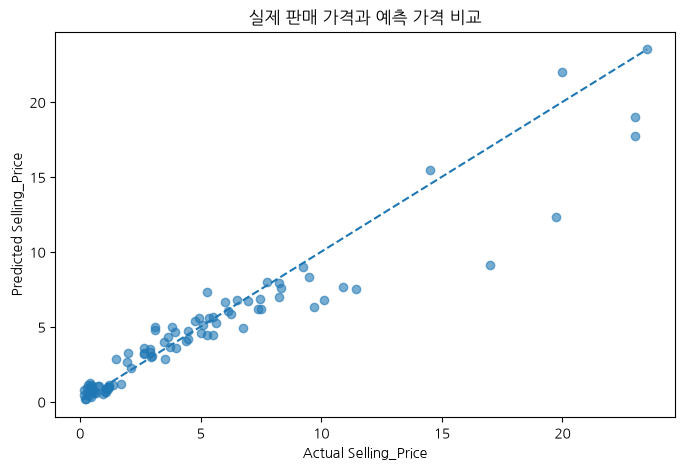

In [33]:
plot_min = min(result_df["actual"].min(), result_df["pred"].min())
plot_max = max(result_df["actual"].max(), result_df["pred"].max())
plt.plot([plot_min, plot_max], [plot_min, plot_max], linestyle="--")
plt.scatter(result_df["actual"], result_df["pred"], alpha=0.6)
plt.xlabel("Actual Selling_Price")
plt.ylabel("Predicted Selling_Price")
plt.title("실제 판매 가격과 예측 가격 비교")

plt.show()

In [34]:
print("[예측 결과 앞부분 10개]")
display(result_df.head(10))

print("[APE가 큰 데이터 10개]")
display(result_df.sort_values("ape", ascending=False).head(10))

[예측 결과 앞부분 10개]


,actual,pred,error,abs_error,ape
177,0.35,1.121120,-0.771120,0.771120,2.203200
289,10.11,6.801727,3.308273,3.308273,0.327228
228,4.95,5.604999,-0.654999,0.654999,0.132323
198,0.15,0.417212,-0.267212,0.267212,1.781414
60,6.95,6.745696,0.204304,0.204304,0.029396
9,7.45,6.874270,0.575730,0.575730,0.077279
118,1.10,0.846913,0.253087,0.253087,0.230079
154,0.50,0.694905,-0.194905,0.194905,0.389809
164,0.45,0.905520,-0.455520,0.455520,1.012267
33,6.00,6.676932,-0.676932,0.676932,0.112822


[APE가 큰 데이터 10개]


,actual,pred,error,abs_error,ape
195,0.18,0.766070,-0.586070,0.586070,3.255942
177,0.35,1.121120,-0.771120,0.771120,2.203200
173,0.40,1.268060,-0.868060,0.868060,2.170151
181,0.30,0.890565,-0.590565,0.590565,1.968551
198,0.15,0.417212,-0.267212,0.267212,1.781414
165,0.45,1.126458,-0.676458,0.676458,1.503240
158,0.48,1.035965,-0.555965,0.555965,1.158260
164,0.45,0.905520,-0.455520,0.455520,1.012267
182,0.30,0.567602,-0.267602,0.267602,0.892008
77,1.50,2.819360,-1.319360,1.319360,0.879573


In [ ]:
# 전체 테스트 데이터의 평균 오차율(MAPE) 확인하기
final_mape = result_df["ape"].mean() * 100
print(f"우리 모델의 최종 평균 오차율: {final_mape:.2f}%")

우리 모델의 최종 평균 오차율: 36.42%


### 13. 제출용 결과 한 번에 확인

실습 결과물에 필요한 핵심 값을 표로 정리합니다.

In [35]:
summary_df = pd.DataFrame(
    [
        ["데이터 행 수", len(df), "원본 데이터 행 개수"],
        ["데이터 열 수", 9, "원본 데이터 열 개수"],
        ["기준 연도", 2026, "Car_Age 계산 기준"],
        ["Train 행 수", len(X_train), "학습 데이터"],
        ["Test 행 수", len(X_test), "평가 데이터"],
        ["Baseline 예측값", baseline_value, "y_train 평균"],
        ["Baseline MAPE(%)", baseline_mape * 100, "낮을수록 좋음"],
        ["Model MAPE(%)", model_mape * 100, "낮을수록 좋음"],
        ["Baseline 대비 개선율(%)", improvement * 100, "양수이면 개선"],
        ["음수 예측 수(보정 전)", int((test_pred < 0).sum()), "0으로 보정"],
        ["R-squared", model.rsquared, "Train 설명력"],
        ["Adjusted R-squared", model.rsquared_adj, "변수 수 보정 설명력"],
        ["유의 변수 수", len(significant_vars), f"p < {0.05}"],
    ],
    columns=["항목", "값", "설명"],
)

target_corr_top2_df = target_corr_top2.rename("correlation").reset_index()
target_corr_top2_df.columns = ["variable", "correlation"]

coefficients_df = pd.DataFrame(
    {
        "variable": model.params.index,
        "coefficient": model.params.values,
        "p_value": model.pvalues.values,
        "std_error": model.bse.values,
        "t_value": model.tvalues.values,
        "ci_lower_95": model.conf_int()[0].values,
        "ci_upper_95": model.conf_int()[1].values,
    }
)
coefficients_df["significant_0.05"] = (
    coefficients_df["p_value"] < 0.05
)

print("[회귀 분석 결과]")
display(summary_df)
print("[통계적으로 유의한 변수]")
display(significant_vars_df)
print("[종속변수와 상관성이 높은 2개 변수]")
display(target_corr_top2_df)
print("[설명변수 간 상관성이 높은 2개 변수쌍]")
display(top_feature_pairs_df)

[회귀 분석 결과]


,항목,값,설명
0,데이터 행 수,301.000000,원본 데이터 행 개수
1,데이터 열 수,9.000000,원본 데이터 열 개수
2,기준 연도,2026.000000,Car_Age 계산 기준
3,Train 행 수,210.000000,학습 데이터
4,Test 행 수,91.000000,평가 데이터
5,Baseline 예측값,4.573238,y_train 평균
6,Baseline MAPE(%),338.200556,낮을수록 좋음
7,Model MAPE(%),36.423334,낮을수록 좋음
8,Baseline 대비 개선율(%),89.230256,양수이면 개선
9,음수 예측 수(보정 전),0.000000,0으로 보정


[통계적으로 유의한 변수]


,variable,p_value,coefficient
0,Seller_Type_Individual,3.120351e-51,-0.912537
1,Present_Price,9.860995e-35,3.503080
2,Car_Age,1.774763e-12,-0.921145
3,Fuel_Type_Diesel,2.147847e-02,0.429204


[종속변수와 상관성이 높은 2개 변수]


,variable,correlation
0,Present_Price,0.878983
1,Fuel_Type_Diesel,0.552339


[설명변수 간 상관성이 높은 2개 변수쌍]


,변수 1,변수 2,상관계수
0,Fuel_Type_Diesel,Fuel_Type_Petrol,-0.979648
1,Kms_Driven,Kms_Per_Year,0.966545


### 14. 제출용 Excel 자동 저장

다음 시트를 포함하는 Excel 파일을 생성합니다.

- `요약`
- `유의변수`
- `Target상관Top2`
- `설명변수상관Top2`
- `회귀계수전체`
- `예측결과`
- `전처리데이터`

Excel 생성이 안되는 경우에는 아래 결과를 유사 양식에 옮겨 적으면 됩니다.

In [37]:
# ==============================
# 사용자 설정
# ==============================
USER_NAME = "최길동"          # 예: "최길동"

OUTPUT_XLSX = f"종합실습_결과물_기초통계_{USER_NAME}.xlsx"
OUTPUT_SUMMARY_CSV = f"종합실습_결과요약_기초통계_{USER_NAME}.csv"

In [38]:
def save_excel_results(output_path: str):
    """분석 결과를 여러 시트로 구성한 Excel 파일로 저장한다."""
    try:
        with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
            summary_df.to_excel(writer, sheet_name="요약", index=False)
            significant_vars_df.to_excel(
                writer, sheet_name="유의변수", index=False
            )
            target_corr_top2_df.to_excel(
                writer, sheet_name="Target상관Top2", index=False
            )
            top_feature_pairs_df.to_excel(
                writer, sheet_name="설명변수상관Top2", index=False
            )
            coefficients_df.to_excel(
                writer, sheet_name="회귀계수전체", index=False
            )
            result_df.to_excel(writer, sheet_name="예측결과", index=True)
            model_df.to_excel(writer, sheet_name="전처리데이터", index=False)

        # 기본적인 가독성 서식: 헤더 강조, 틀 고정, 필터, 열 너비 조정
        from openpyxl import load_workbook
        from openpyxl.styles import Alignment, Font, PatternFill

        workbook = load_workbook(output_path)
        header_fill = PatternFill("solid", fgColor="0F766E")
        header_font = Font(color="FFFFFF", bold=True)

        for worksheet in workbook.worksheets:
            worksheet.freeze_panes = "A2"
            worksheet.auto_filter.ref = worksheet.dimensions

            for cell in worksheet[1]:
                cell.fill = header_fill
                cell.font = header_font
                cell.alignment = Alignment(horizontal="center")

            for column_cells in worksheet.columns:
                column_letter = column_cells[0].column_letter
                max_length = max(
                    len(str(cell.value)) if cell.value is not None else 0
                    for cell in column_cells[:300]
                )
                worksheet.column_dimensions[column_letter].width = min(
                    max(max_length + 2, 10), 32
                )

        workbook.save(output_path)
    except ImportError as error:
        raise ImportError(
            "Excel 저장에 필요한 openpyxl이 없습니다. "
            "Colab에서 `%pip install openpyxl` 실행 후 다시 시도하세요."
        ) from error


save_excel_results(OUTPUT_XLSX)
summary_df.to_csv(OUTPUT_SUMMARY_CSV, index=False, encoding="utf-8-sig")

from pathlib import Path
print("✅ Excel 저장 완료:", Path(OUTPUT_XLSX).resolve())
print("✅ 요약 CSV 저장 완료:", Path(OUTPUT_SUMMARY_CSV).resolve())

✅ Excel 저장 완료: /workspaces/git-profile-lab-honggildong/종합실습_결과물_기초통계_최길동.xlsx
✅ 요약 CSV 저장 완료: /workspaces/git-profile-lab-honggildong/종합실습_결과요약_기초통계_최길동.csv


### 15. 자동 검증 체크리스트

모델 성능뿐 아니라 데이터 구조, 전처리, 분할, 결과 파일 생성 여부를 함께 검사합니다. 모든 항목이 `PASS`이면 노트북이 정상적으로 끝까지 실행된 것입니다.

In [39]:
checks = {
    "원본 데이터가 301행이다": len(df) == 301,
    "원본 데이터가 9개 컬럼이다": len(REQUIRED_COLUMNS) == 9,
    "필수 컬럼이 모두 존재한다": not missing_columns,
    "원본 결측치가 없다": int(df[REQUIRED_COLUMNS].isna().sum().sum()) == 0,
    "파생변수에 비정상 값이 없다": np.isfinite(
        df[["Car_Age", "Kms_Per_Year"]].to_numpy(dtype=float)
    ).all(),
    "전처리 후 문자열 컬럼이 없다": not remaining_object_cols,
    "Train/Test 행 수 합계가 301이다": len(X_train) + len(X_test) == 301,
    "Train 행 수가 210이다": len(X_train) == 210,
    "Test 행 수가 91이다": len(X_test) == 91,
    "모델 MAPE가 Baseline보다 낮다": model_mape < baseline_mape,
    "첫 번째 Target 상관변수가 Present_Price다": (
        target_corr_top2.index[0] == "Present_Price"
    ),
    "유의 변수가 1개 이상이다": len(significant_vars) > 0,
    "예측값이 모두 0 이상이다": (test_pred >= 0).all(),
    "Excel 결과 파일이 생성되었다": Path(OUTPUT_XLSX).exists(),
}

check_df = pd.DataFrame(
    {
        "검증 항목": list(checks.keys()),
        "통과 여부": ["PASS" if value else "FAIL" for value in checks.values()],
    }
)
display(check_df)

failed_checks = [name for name, passed in checks.items() if not passed]
if failed_checks:
    raise AssertionError("검증 실패 항목: " + ", ".join(failed_checks))

# 기준 구현과 크게 다른 결과인지 추가 확인한다.
reference_metrics = {
    "Baseline MAPE(%)": 338.20,
    "Model MAPE(%)": 67.45,
    "개선율(%)": 80.06,
    "R-squared": 0.8828,
}
current_metrics = {
    "Baseline MAPE(%)": baseline_mape * 100,
    "Model MAPE(%)": model_mape * 100,
    "개선율(%)": improvement * 100,
    "R-squared": model.rsquared,
}
comparison_rows = []
for metric, reference_value in reference_metrics.items():
    current_value = current_metrics[metric]
    comparison_rows.append(
        {
            "지표": metric,
            "현재 실행값": current_value,
            "참고 기준값": reference_value,
            "차이": current_value - reference_value,
        }
    )

print("✅ 모든 자동 검증을 통과했습니다.")
print("[참고 기준값 비교: 버전에 따라 미세한 차이가 날 수 있음]")
display(pd.DataFrame(comparison_rows))

,검증 항목,통과 여부
0,원본 데이터가 301행이다,PASS
1,원본 데이터가 9개 컬럼이다,PASS
2,필수 컬럼이 모두 존재한다,PASS
3,원본 결측치가 없다,PASS
4,파생변수에 비정상 값이 없다,PASS
5,전처리 후 문자열 컬럼이 없다,PASS
6,Train/Test 행 수 합계가 301이다,PASS
7,Train 행 수가 210이다,PASS
8,Test 행 수가 91이다,PASS
9,모델 MAPE가 Baseline보다 낮다,PASS


✅ 모든 자동 검증을 통과했습니다.
[참고 기준값 비교: 버전에 따라 미세한 차이가 날 수 있음]


,지표,현재 실행값,참고 기준값,차이
0,Baseline MAPE(%),338.200556,338.2000,0.000556
1,Model MAPE(%),36.423334,67.4500,-31.026666
2,개선율(%),89.230256,80.0600,9.170256
3,R-squared,0.903647,0.8828,0.020847
